# 01 Data Inspection

Initial inspection of the ASHRAE Great Energy Predictor III raw files.

This notebook checks file availability, basic shape, columns, missing values, date ranges, and the electricity meter records used for modeling.

## Setup

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

In [3]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"

RAW_FILES = {
    "train": RAW_DATA_DIR / "train.csv",
    "building_metadata": RAW_DATA_DIR / "building_metadata.csv",
    "weather_train": RAW_DATA_DIR / "weather_train.csv",
    "test": RAW_DATA_DIR / "test.csv",
    "weather_test": RAW_DATA_DIR / "weather_test.csv",
    "sample_submission": RAW_DATA_DIR / "sample_submission.csv",
}

RAW_DATA_DIR

PosixPath('/Users/srs/Desktop/PROJECTS/commercial-building-energy-prediction/data/raw')

## Raw File Inventory

In [4]:
file_inventory = []

for name, path in RAW_FILES.items():
    file_inventory.append(
        {
            "name": name,
            "path": path.relative_to(PROJECT_ROOT),
            "exists": path.exists(),
            "size_mb": round(path.stat().st_size / 1024**2, 2) if path.exists() else None,
        }
    )

pd.DataFrame(file_inventory)

,name,path,exists,size_mb
0,train,data/raw/train.csv,True,647.18
1,building_metadata,data/raw/building_metadata.csv,True,0.04
2,weather_train,data/raw/weather_train.csv,True,7.10
3,test,data/raw/test.csv,True,1394.71
4,weather_test,data/raw/weather_test.csv,True,14.10
5,sample_submission,data/raw/sample_submission.csv,True,426.83


## Helper Functions

In [5]:
def read_sample(path: Path, rows: int = 100_000) -> pd.DataFrame:
    """Read a small sample from a CSV file for fast inspection."""
    return pd.read_csv(path, nrows=rows)


def inspect_frame(frame: pd.DataFrame) -> pd.DataFrame:
    """Summarize columns, dtypes, missing values, and uniqueness."""
    return pd.DataFrame(
        {
            "column": frame.columns,
            "dtype": frame.dtypes.astype(str).values,
            "missing": frame.isna().sum().values,
            "missing_pct": (frame.isna().mean() * 100).round(2).values,
            "unique_values": frame.nunique(dropna=True).values,
        }
    )

## Load Samples

In [6]:
train_sample = read_sample(RAW_FILES["train"])
building_metadata = pd.read_csv(RAW_FILES["building_metadata"])
weather_train_sample = read_sample(RAW_FILES["weather_train"])
test_sample = read_sample(RAW_FILES["test"])
weather_test_sample = read_sample(RAW_FILES["weather_test"])
sample_submission_sample = read_sample(RAW_FILES["sample_submission"])

samples = {
    "train_sample": train_sample,
    "building_metadata": building_metadata,
    "weather_train_sample": weather_train_sample,
    "test_sample": test_sample,
    "weather_test_sample": weather_test_sample,
    "sample_submission_sample": sample_submission_sample,
}

In [24]:
train_sample.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   building_id    100000 non-null  int64         
 1   meter          100000 non-null  int64         
 2   timestamp      100000 non-null  datetime64[ns]
 3   meter_reading  100000 non-null  float64       
dtypes: datetime64[ns](1), float64(1), int64(2)
memory usage: 3.1 MB


In [26]:
pd.DataFrame(
    [
        {"dataset": name, "rows": len(frame), "columns": frame.shape[1]}
        for name, frame in samples.items()
    ]
)

,dataset,rows,columns
0,train_sample,100000,4
1,building_metadata,1449,6
2,weather_train_sample,100000,9
3,test_sample,100000,4
4,weather_test_sample,100000,9
5,sample_submission_sample,100000,2


## Column Inspection

In [8]:
for name, frame in samples.items():
    print(f"\n{name}")
    display(inspect_frame(frame))


train_sample


,column,dtype,missing,missing_pct,unique_values
0,building_id,int64,0,0.0,1426
1,meter,int64,0,0.0,4
2,timestamp,object,0,0.0,44
3,meter_reading,float64,0,0.0,46534



building_metadata


,column,dtype,missing,missing_pct,unique_values
0,site_id,int64,0,0.00,16
1,building_id,int64,0,0.00,1449
2,primary_use,object,0,0.00,16
3,square_feet,int64,0,0.00,1397
4,year_built,float64,774,53.42,116
5,floor_count,float64,1094,75.50,18



weather_train_sample


...

,column,dtype,missing,missing_pct,unique_values
0,row_id,int64,0,0.0,100000
1,building_id,int64,0,0.0,105
2,meter,int64,0,0.0,2
3,timestamp,object,0,0.0,776



weather_test_sample


,column,dtype,missing,missing_pct,unique_values
0,site_id,int64,0,0.00,6
1,timestamp,object,0,0.00,17520
2,air_temperature,float64,24,0.02,421
3,cloud_coverage,float64,51088,51.09,6
4,dew_temperature,float64,30,0.03,326
5,precip_depth_1_hr,float64,30304,30.30,97
6,sea_level_pressure,float64,13542,13.54,610
7,wind_direction,float64,2515,2.51,37
8,wind_speed,float64,20,0.02,47



sample_submission_sample


,column,dtype,missing,missing_pct,unique_values
0,row_id,int64,0,0.0,100000
1,meter_reading,int64,0,0.0,1


## Preview Raw Tables

In [9]:
train_sample.head()

,building_id,meter,timestamp,meter_reading
0,0,0,2016-01-01 00:00:00,0.0
1,1,0,2016-01-01 00:00:00,0.0
2,2,0,2016-01-01 00:00:00,0.0
3,3,0,2016-01-01 00:00:00,0.0
4,4,0,2016-01-01 00:00:00,0.0


In [10]:
building_metadata.head()

,site_id,building_id,primary_use,square_feet,year_built,floor_count
0,0,0,Education,7432,2008.0,NaN
1,0,1,Education,2720,2004.0,NaN
2,0,2,Education,5376,1991.0,NaN
3,0,3,Education,23685,2002.0,NaN
4,0,4,Education,116607,1975.0,NaN


In [11]:
weather_train_sample.head()

,site_id,timestamp,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed
0,0,2016-01-01 00:00:00,25.0,6.0,20.0,NaN,1019.7,0.0,0.0
1,0,2016-01-01 01:00:00,24.4,NaN,21.1,-1.0,1020.2,70.0,1.5
2,0,2016-01-01 02:00:00,22.8,2.0,21.1,0.0,1020.2,0.0,0.0
3,0,2016-01-01 03:00:00,21.1,2.0,20.6,0.0,1020.1,0.0,0.0
4,0,2016-01-01 04:00:00,20.0,2.0,20.0,-1.0,1020.0,250.0,2.6


## Training Data Checks

In [27]:
train_sample["timestamp"] = pd.to_datetime(train_sample["timestamp"])

training_summary = {
    "sample_rows": len(train_sample),
    "building_count": train_sample["building_id"].nunique(),
    "meter_count": train_sample["meter"].nunique(),
    "start_timestamp": train_sample["timestamp"].min(),
    "end_timestamp": train_sample["timestamp"].max(),
    "zero_meter_reading_pct": round((train_sample["meter_reading"] == 0).mean() * 100, 2),
}

summary_df = (
    pd.DataFrame.from_dict(
        training_summary,
        orient="index",
        columns=["Value"]
    )
    .rename_axis("Metric")
    .reset_index()
)

summary_df

,Metric,Value
0,sample_rows,100000
1,building_count,1426
2,meter_count,4
3,start_timestamp,2016-01-01 00:00:00
4,end_timestamp,2016-01-02 19:00:00
5,zero_meter_reading_pct,13.03


In [13]:
train_sample["meter"].value_counts().sort_index().rename_axis("meter").reset_index(name="sample_rows")

,meter,sample_rows
0,0,60567
1,1,19704
2,2,13533
3,3,6196


Meter meanings from the competition:

- `0`: electricity
- `1`: chilled water
- `2`: steam
- `3`: hot water

## Electricity Meter Preview

In [14]:
electricity_sample = train_sample.loc[train_sample["meter"] == 0].copy()
electricity_sample.describe(include="all")

,building_id,meter,timestamp,meter_reading
count,60567.000000,60567.0,60567,60567.000000
mean,711.717833,0.0,2016-01-01 21:19:45.318737920,127.531922
min,0.000000,0.0,2016-01-01 00:00:00,0.000000
25%,348.000000,0.0,2016-01-01 10:00:00,12.431250
50%,705.000000,0.0,2016-01-01 21:00:00,43.000000
75%,1069.000000,0.0,2016-01-02 08:00:00,122.250000
max,1448.000000,0.0,2016-01-02 19:00:00,4908.140000
std,418.014567,0.0,NaN,297.488933


In [15]:
electricity_sample["meter_reading"].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])

count    60567.000000
mean       127.531922
std        297.488933
min          0.000000
1%           0.000000
5%           0.000000
25%         12.431250
50%         43.000000
75%        122.250000
95%        504.688000
99%       1261.360000
max       4908.140000
Name: meter_reading, dtype: float64

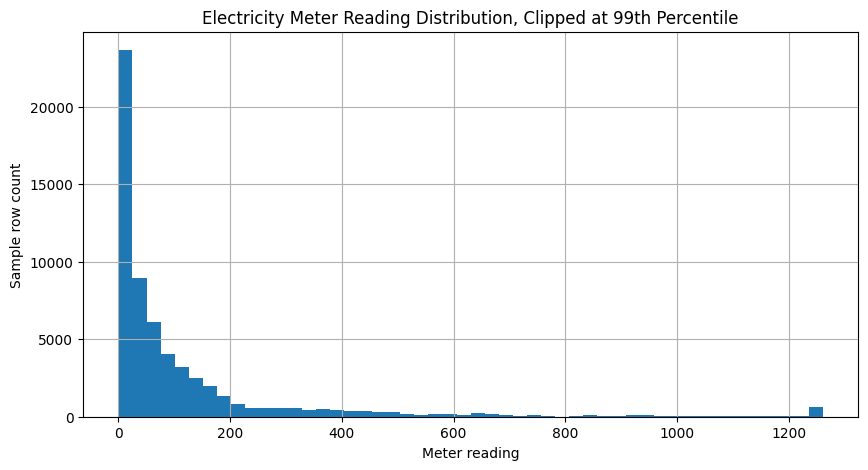

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
electricity_sample["meter_reading"].clip(upper=electricity_sample["meter_reading"].quantile(0.99)).hist(
    bins=50,
    ax=ax,
)
ax.set_title("Electricity Meter Reading Distribution, Clipped at 99th Percentile")
ax.set_xlabel("Meter reading")
ax.set_ylabel("Sample row count")
plt.show()

## Building Metadata Checks

In [17]:
building_metadata["primary_use"].value_counts().reset_index().rename(
    columns={"index": "primary_use", "primary_use": "building_count"}
)

,building_count,count
0,Education,549
1,Office,279
2,Entertainment/public assembly,184
3,Public services,156
4,Lodging/residential,147
5,Other,25
6,Healthcare,23
7,Parking,22
8,Warehouse/storage,13
9,Manufacturing/industrial,12


In [18]:
building_metadata.describe(include="all")

,site_id,building_id,primary_use,square_feet,year_built,floor_count
count,1449.000000,1449.000000,1449,1449.000000,675.000000,355.000000
unique,NaN,NaN,16,NaN,NaN,NaN
top,NaN,NaN,Education,NaN,NaN,NaN
freq,NaN,NaN,549,NaN,NaN,NaN
mean,6.952381,724.000000,NaN,92111.776398,1967.957037,3.740845
std,5.003432,418.434583,NaN,110769.950997,31.054030,3.333683
min,0.000000,0.000000,NaN,283.000000,1900.000000,1.000000
25%,3.000000,362.000000,NaN,23012.000000,1949.000000,1.000000
50%,5.000000,724.000000,NaN,57673.000000,1970.000000,3.000000
75%,13.000000,1086.000000,NaN,115676.000000,1995.000000,5.000000


## Weather Checks

In [28]:
weather_train_sample["timestamp"] = pd.to_datetime(weather_train_sample["timestamp"])

weather_summary = {
    "sample_rows": len(weather_train_sample),
    "site_count": weather_train_sample["site_id"].nunique(),
    "start_timestamp": weather_train_sample["timestamp"].min(),
    "end_timestamp": weather_train_sample["timestamp"].max(),
}

weather_df = (
    pd.DataFrame.from_dict(
        training_summary,
        orient="index",
        columns=["Value"]
    )
    .rename_axis("Metric")
    .reset_index()
)

weather_df

,Metric,Value
0,sample_rows,100000
1,building_count,1426
2,meter_count,4
3,start_timestamp,2016-01-01 00:00:00
4,end_timestamp,2016-01-02 19:00:00
5,zero_meter_reading_pct,13.03


In [20]:
inspect_frame(weather_train_sample)

,column,dtype,missing,missing_pct,unique_values
0,site_id,int64,0,0.00,12
1,timestamp,datetime64[ns],0,0.00,8784
2,air_temperature,float64,53,0.05,612
3,cloud_coverage,float64,52102,52.10,6
4,dew_temperature,float64,95,0.10,518
5,precip_depth_1_hr,float64,30143,30.14,119
6,sea_level_pressure,float64,9816,9.82,642
7,wind_direction,float64,5518,5.52,42
8,wind_speed,float64,252,0.25,47


## Join Feasibility Check

In [31]:
train_with_buildings = train_sample.merge(building_metadata, on="building_id", how="left")
train_with_weather = train_with_buildings.merge(
    weather_train_sample,
    on=["site_id", "timestamp"],
    how="left",
)

join_check = {
    "Train Sample Rows": len(train_sample),
    "Joined Rows": len(train_with_weather),
    "Missing Site ID (%)": round(
        train_with_weather["site_id"].isna().mean() * 100, 2
    ),
    "Missing Air Temperature (%)": round(
        train_with_weather["air_temperature"].isna().mean() * 100, 2
    ),
}

join_check_df = (
    pd.DataFrame.from_dict(
        join_check,
        orient="index",
        columns=["Value"]
    )
    .rename_axis("Metric")
    .reset_index()
)

join_check_df

,Metric,Value
0,Train Sample Rows,100000.00
1,Joined Rows,100000.00
2,Missing Site ID (%),0.00
3,Missing Air Temperature (%),37.78


## Notes and Next Questions

Use this section to record observations before building preprocessing or modeling code.

- Which columns have the most missing values?
- How much of the training sample is electricity meter data?
- Are zero meter readings common enough to need special handling?
- Which building types and sites dominate the dataset?
- What preprocessing choices should be made before EDA and modeling?